# 관악구 센서 전체 인벤토리 (침수 여부 무관)

관악구 **하수관로 13 + 도로노면 5 = 18 센서**의 위치·제원·데이터·품질·침수/만관 상태를 한 곳에 정리.
(자치구='관악구' 기준. GIS 공간범위로는 경계 인접 17/20/22번 센서가 추가되나 여기선 공식 관할 기준.)

In [1]:
import os; os.chdir("/home/namjun/city_flood")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams['font.family']=['DejaVu Sans']
EB="dataset/processed/eda_based/"
# 하수
sn=pd.read_parquet("dataset/processed/cleaned/sewer_node.parquet",columns=['sensor_id','지점명','배수구역','자치구','관규격','lat','lon'])
sew=sn[sn.자치구=='관악구'].copy()
rel=pd.read_parquet(EB+"sewer_capacity_reliability.parquet")[['sensor_id','capacity_판정']]
au=pd.read_parquet(EB+"sewer_surcharge_audit.parquet")[['sewer_sensor_id','최종판정']]
q=pd.read_parquet(EB+"sewer_sensor_quality.parquet")
sf=pd.read_parquet(EB+"sewer_features_10min.parquet",columns=['sewer_sensor_id','ts10','fill_rate','level_max_10m'],filters=[('sewer_sensor_id','in',sew.sensor_id.tolist())])
ag=sf.groupby('sewer_sensor_id').agg(n=('ts10','size'),t0=('ts10','min'),t1=('ts10','max'),lvl중앙=('level_max_10m','median'),fill최대=('fill_rate','max')).reset_index().rename(columns={'sewer_sensor_id':'sensor_id'})
sew=sew.merge(ag,on='sensor_id',how='left').merge(rel,on='sensor_id',how='left').merge(au,left_on='sensor_id',right_on='sewer_sensor_id',how='left')
sew['grade']=sew.sensor_id.map(q.grade); sew['상태']=sew.최종판정.fillna('만관無')
sew['type']='하수관로'
# 도로
rn=pd.read_parquet("dataset/processed/cleaned/road_node.parquet",columns=['sensor_id','지점명','배수구역','자치구','lat','lon'])
road=rn[rn.자치구=='관악구청'].copy()
trust=pd.read_parquet(EB+"road_flood_sensor_trust.parquet")[['sensor_id','판정_final']]
rp=pd.read_parquet(EB+"road_panel_10min.parquet",columns=['sensor_id','ts10','road_adj_max','flood_t6','grade'])
rpa=rp[rp.sensor_id.isin(road.sensor_id)]
rag=rpa.groupby('sensor_id').agg(n=('ts10','size'),t0=('ts10','min'),t1=('ts10','max'),침수=('flood_t6','sum'),grade=('grade','first')).reset_index()
road=road.merge(rag,on='sensor_id',how='left').merge(trust,on='sensor_id',how='left')
road['상태']=road.판정_final; road['type']='도로노면'
print("하수",len(sew),"| 도로",len(road))

하수 13 | 도로 5


## 통합 인벤토리 저장

In [2]:
inv=pd.concat([
 sew.assign(기간=sew.t0.dt.strftime('%y.%m')+'~'+sew.t1.dt.strftime('%y.%m'))[['sensor_id','type','지점명','배수구역','관규격','grade','기간','n','상태','lat','lon']],
 road.assign(기간=road.t0.dt.strftime('%y.%m')+'~'+road.t1.dt.strftime('%y.%m'),관규격='-')[['sensor_id','type','지점명','배수구역','관규격','grade','기간','n','상태','lat','lon']]
],ignore_index=True)
inv.to_parquet(EB+"gwanak_sensor_inventory.parquet",index=False)
print(inv.drop(columns=['lat','lon']).to_string(index=False))

  sensor_id type             지점명 배수구역       관규격 grade          기간      n   상태
    21-0001 하수관로       삼성808-540  안양천 2@3.0X2.0     A 22.01~25.08 161213  만관無
    21-0002 하수관로        조원547-31  안양천 4@3.0X2.4     A 22.01~25.08 185188  만관無
    21-0003 하수관로        미성1567-9  안양천 1@6.0X2.5     B 22.01~25.08 147955  만관無
    21-0004 하수관로       낙성대1620-2  안양천 1@4.0X3.0     B 22.01~25.08 185119  만관無
    21-0005 하수관로        보라매968-5  안양천 1@3.9X3.1     A 22.01~25.08 185191  만관無
    21-0006 하수관로        행운1669-1  안양천 2@4.0X3.0     B 22.01~25.08 185246  만관無
    21-0007 하수관로      신림 1450-13  안양천 1@3.0X1.9     B 22.01~25.08 185280  만관無
    21-0008 하수관로         난곡로 351  안양천 2@4.0X3.0     B 23.12~25.08  77865  만관無
    21-0009 하수관로         신사로 108  안양천   3.0×1.5     B 24.11~25.08  12348  만관無
    21-0010 하수관로       조원로13길 72  안양천      Ø450     B 24.11~25.08   9370  만관無
    21-0011 하수관로          신원로 18  안양천   2.5×2.0     B 24.11~25.08  15075  만관無
    21-0012 하수관로       신림로71길 45  안양천   3.0×2.0     B 24.11~25.0

## 위치 지도

/tmp/ipykernel_317182/432695757.py:16: UserWarning: Glyph 48393 (\N{HANGUL SYLLABLE BONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); os.makedirs('reports/figures_gnn',exist_ok=True)
/tmp/ipykernel_317182/432695757.py:16: UserWarning: Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); os.makedirs('reports/figures_gnn',exist_ok=True)
/tmp/ipykernel_317182/432695757.py:16: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); os.makedirs('reports/figures_gnn',exist_ok=True)
/tmp/ipykernel_317182/432695757.py:16: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); os.makedirs('reports/figures_gnn',exist_ok=True)
/tmp/ipykernel_317182/432695757.py:16: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); os.makedirs('reports/figures_gnn',exist_ok=True)
/tmp/ipykernel_317182/4

/home/namjun/city_flood/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48393 (\N{HANGUL SYLLABLE BONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/namjun/city_flood/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/namjun/city_flood/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/namjun/city_flood/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/namjun/city_flood/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44600 (\N{HANGUL

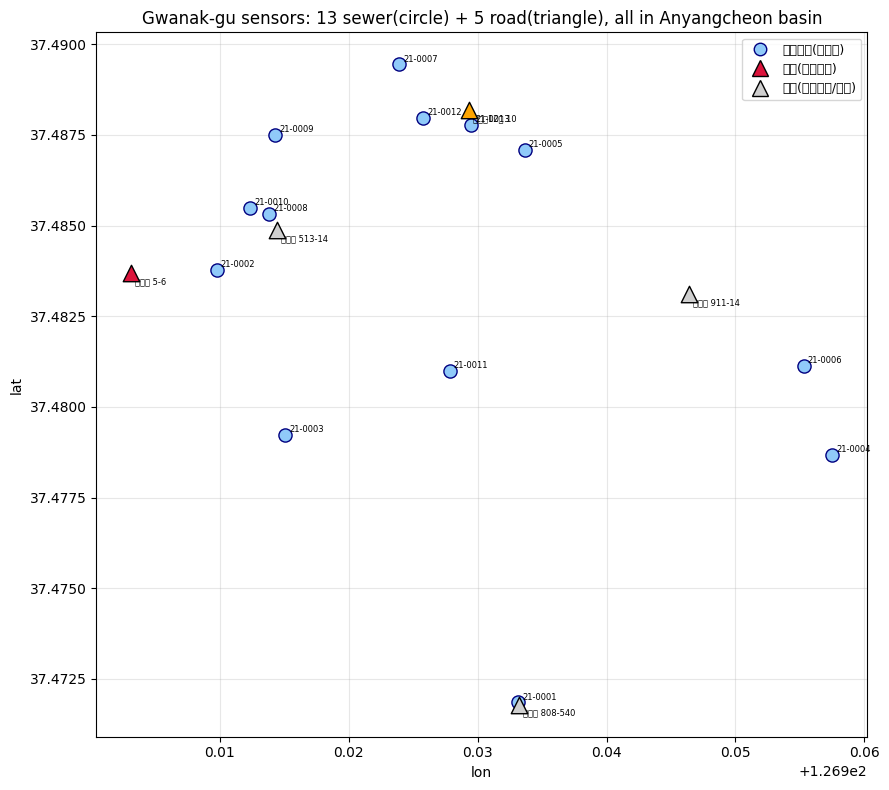

saved


In [3]:
fig,ax=plt.subplots(figsize=(9,8))
cmap={'만관無':'#90caf9','진짜상습':'crimson','아티팩트':'#cfcfcf','미결':'orange'}
for _,r in sew.iterrows():
    ax.scatter(r.lon,r.lat,s=90,marker='o',c=cmap.get(r.상태,'#90caf9'),edgecolor='navy',zorder=3)
    ax.annotate(r.sensor_id,(r.lon,r.lat),fontsize=6,xytext=(3,2),textcoords='offset points')
for _,r in road.iterrows():
    ax.scatter(r.lon,r.lat,s=140,marker='^',c=cmap.get(r.상태,'gray'),edgecolor='k',zorder=4)
    ax.annotate(r.sensor_id.replace('관악구 ',''),(r.lon,r.lat),fontsize=6,xytext=(3,-8),textcoords='offset points')
from matplotlib.lines import Line2D
leg=[Line2D([0],[0],marker='o',color='w',markerfacecolor='#90caf9',markeredgecolor='navy',markersize=9,label='하수관로(만관無)'),
     Line2D([0],[0],marker='^',color='w',markerfacecolor='crimson',markeredgecolor='k',markersize=11,label='도로(진짜상습)'),
     Line2D([0],[0],marker='^',color='w',markerfacecolor='#cfcfcf',markeredgecolor='k',markersize=11,label='도로(아티팩트/미결)')]
ax.legend(handles=leg,fontsize=9,loc='best')
ax.set_title('Gwanak-gu sensors: 13 sewer(circle) + 5 road(triangle), all in Anyangcheon basin')
ax.set_xlabel('lon'); ax.set_ylabel('lat'); ax.grid(alpha=.3)
plt.tight_layout(); os.makedirs('reports/figures_gnn',exist_ok=True)
plt.savefig('reports/figures_gnn/05_gwanak_inventory.png',dpi=110,bbox_inches='tight'); plt.show(); print('saved')

## 요약
- **관악구 센서 = 하수관로 13 + 도로노면 5 = 18개**, 전부 **안양천 배수구역**(도림천·안양천 저지대).
- **하수 13개: 전부 만관(surcharge) 0건**, fill 최대 0.65~0.92. capacity 전부 신뢰. = 관악 하수는 안 참.
- **도로 5개: 진짜상습 1(조원로5-6) / 아티팩트 3 / 미결 1**. 조원로 침수 80%가 여름이나 강우동반 낮음 = 하천역류·표면류 추정.
- 데이터 기간: 하수 다수 2022~(장기), 일부 2024-11~(단기); 도로 2024~.